In [3]:
from google.colab import files
uploaded = files.upload()

Saving loan_approval_dataset.csv to loan_approval_dataset.csv


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

In [4]:
df = pd.read_csv('loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [7]:
df = df.drop('loan_id',axis=1)
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [8]:
df.columns.tolist()

[' no_of_dependents',
 ' education',
 ' self_employed',
 ' income_annum',
 ' loan_amount',
 ' loan_term',
 ' cibil_score',
 ' residential_assets_value',
 ' commercial_assets_value',
 ' luxury_assets_value',
 ' bank_asset_value',
 ' loan_status']

In [9]:
df.isnull().sum()

,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0
luxury_assets_value,0


In [10]:
df.shape

(4269, 12)

In [15]:
df.columns = df.columns.str.strip()
print(df['education'].unique())
print(df['self_employed'].unique())
print(df['loan_status'].unique())

[' Graduate' ' Not Graduate']
[' No' ' Yes']
[' Approved' ' Rejected']


In [16]:
l = LabelEncoder()
df['education'] = l.fit_transform(df['education'])
df['self_employed'] = l.fit_transform(df['self_employed'])
df['loan_status'] = l.fit_transform(df['loan_status'])
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


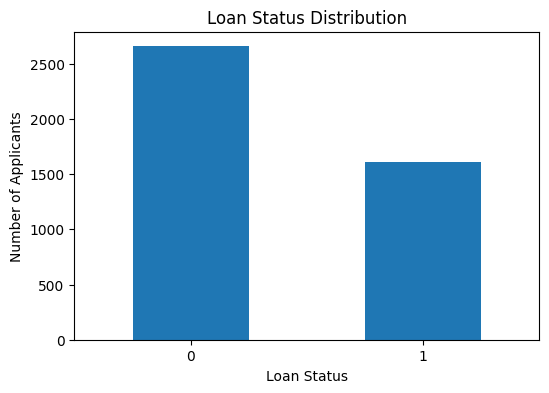

In [19]:
plt.figure(figsize=(6, 4))

df['loan_status'].value_counts().plot(kind='bar')

plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.title("Loan Status Distribution")
plt.xticks(rotation=0)

plt.show()

In [24]:
features = df.drop('loan_status',axis=1)
outliers_counts = {}
for col in features.columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  outliers_counts[col] = len(outliers)
for col, count in outliers_counts.items():
  print(f"Number of outliers in {col}: {count}")

Number of outliers in no_of_dependents: 0
Number of outliers in education: 0
Number of outliers in self_employed: 0
Number of outliers in income_annum: 0
Number of outliers in loan_amount: 0
Number of outliers in loan_term: 0
Number of outliers in cibil_score: 0
Number of outliers in residential_assets_value: 52
Number of outliers in commercial_assets_value: 37
Number of outliers in luxury_assets_value: 0
Number of outliers in bank_asset_value: 5


In [25]:
x = df.drop('loan_status',axis=1)
y = df['loan_status']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify = y)

In [27]:
ss = StandardScaler()
x_train = ss.fit_transform(x_train)
x_test = ss.transform(x_test)

In [29]:
lr_model = LogisticRegression(random_state = 42)
lr_model.fit(x_train,y_train)
lr_pred = lr_model.predict(x_test)
lr_prob = lr_model.predict_proba(x_test)[:,1]
print(accuracy_score(y_test,lr_pred))
print(precision_score(y_test,lr_pred))
print(recall_score(y_test,lr_pred))
print(f1_score(y_test,lr_pred))
print(roc_auc_score(y_test,lr_prob))

0.9227166276346604
0.9158576051779935
0.8761609907120743
0.8955696202531646
0.9745092208753855


In [30]:
print(classification_report(
    y_test,
    lr_pred,
    target_names=["Rejected", "Approved"]
))

              precision    recall  f1-score   support

    Rejected       0.93      0.95      0.94       531
    Approved       0.92      0.88      0.90       323

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.92       854
weighted avg       0.92      0.92      0.92       854



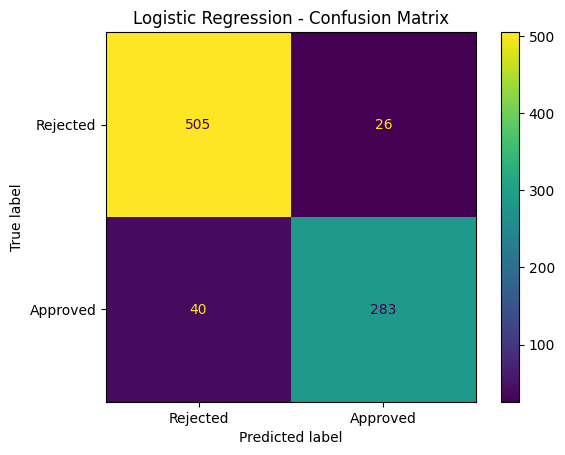

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["Rejected", "Approved"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)
rf_prob = rf_model.predict_proba(x_test)[:, 1]
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Results")
print("=" * 40)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Results
Accuracy : 0.9801
Precision: 0.9842
Recall   : 0.9628
F1 Score : 0.9734
ROC-AUC  : 0.9981


In [34]:
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Rejected", "Approved"]
))

              precision    recall  f1-score   support

    Rejected       0.98      0.99      0.98       531
    Approved       0.98      0.96      0.97       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



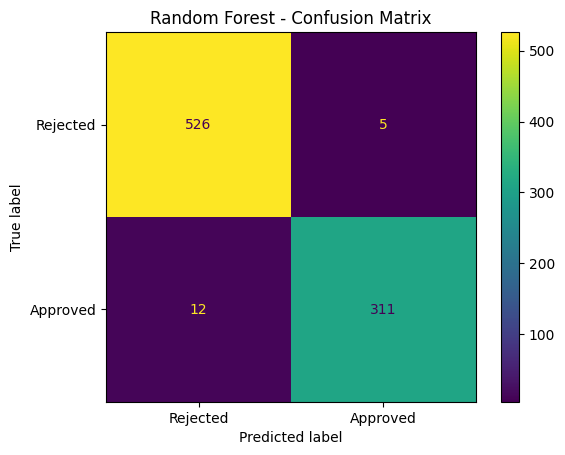

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Rejected", "Approved"]
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [37]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_model.fit(x_train, y_train)
gb_pred = gb_model.predict(x_test)
gb_prob = gb_model.predict_proba(x_test)[:, 1]
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_roc_auc = roc_auc_score(y_test, gb_prob)

print("Gradient Boosting Results")
print("=" * 40)
print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1 Score : {gb_f1:.4f}")
print(f"ROC-AUC  : {gb_roc_auc:.4f}")

Gradient Boosting Results
Accuracy : 0.9836
Precision: 0.9905
Recall   : 0.9659
F1 Score : 0.9781
ROC-AUC  : 0.9983


In [38]:
print(classification_report(
    y_test,
    gb_pred,
    target_names=["Rejected", "Approved"]
))

              precision    recall  f1-score   support

    Rejected       0.98      0.99      0.99       531
    Approved       0.99      0.97      0.98       323

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



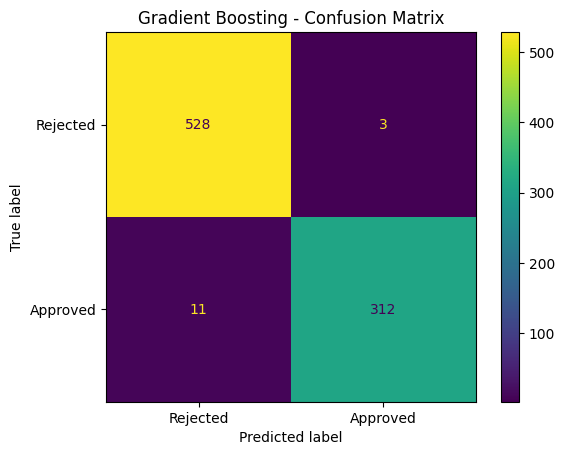

In [39]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    gb_pred,
    display_labels=["Rejected", "Approved"]
)

plt.title("Gradient Boosting - Confusion Matrix")
plt.show()

In [41]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(x_train, y_train)
xgb_pred = xgb_model.predict(x_test)
xgb_prob = xgb_model.predict_proba(x_test)[:, 1]
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost Results")
print("=" * 40)
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

XGBoost Results
Accuracy : 0.9824
Precision: 0.9873
Recall   : 0.9659
F1 Score : 0.9765
ROC-AUC  : 0.9983


In [42]:
print(classification_report(
    y_test,
    xgb_pred,
    target_names=["Rejected", "Approved"]
))

              precision    recall  f1-score   support

    Rejected       0.98      0.99      0.99       531
    Approved       0.99      0.97      0.98       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



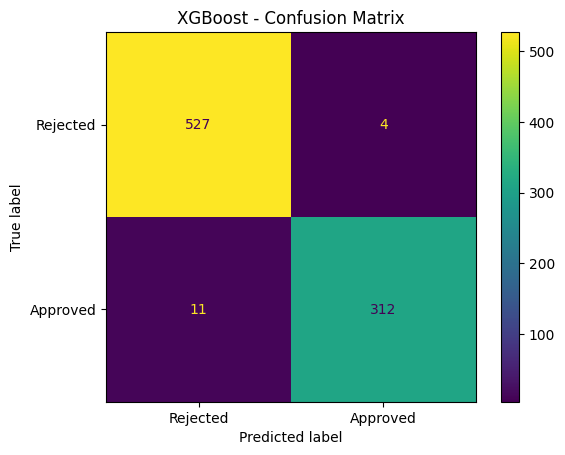

In [43]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=["Rejected", "Approved"]
)

plt.title("XGBoost - Confusion Matrix")
plt.show()

In [44]:
print("Model Comparision")
print("=" * 40)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

Model Comparision
Logistic Regression Accuracy: 0.9227
Random Forest Accuracy: 0.9801
Gradient Boosting Accuracy: 0.9836
XGBoost Accuracy: 0.9824


In [47]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():

    y_pred = model.predict(x_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]
    else:
        y_prob = None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.922717   0.915858  0.876161  0.895570  0.974509
1        Random Forest  0.980094   0.984177  0.962848  0.973396  0.998053
2    Gradient Boosting  0.983607   0.990476  0.965944  0.978056  0.998315
3              XGBoost  0.982436   0.987342  0.965944  0.976526  0.998257
